In [1]:
import wandb
import pandas as pd

api = wandb.Api(api_key="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")

In [6]:
df_b

,_step,train train ce loss avg
0,10,9.419471
1,80,3.317067
2,90,3.156130
3,100,3.009135
4,280,2.002664
...,...,...
495,28410,1.061929
496,28440,1.089378
497,28570,1.089338
498,28580,1.055849


In [7]:
merged

,_step,train train loss avg,train train ce loss avg
0,10,9.432773,9.419471
1,80,3.322997,3.317067
2,90,3.161138,3.156130
3,100,3.009215,3.009135
4,280,2.007752,2.002664
...,...,...,...
491,28030,1.070082,1.079497
492,28140,1.070603,1.080549
493,28170,1.065405,1.075320
494,28250,1.064563,1.074179


In [8]:
# 1. Replace with your actual run paths: "entity/project/run_id"
run_a_path = "behzadshomali/nemotron_24_effective_layers_1B_MATH/mv9e36w0" # small blocks
run_baseline_path = "behzadshomali/nemotron_24_effective_layers_1B_MATH/jg8i37pi"

run_a = api.run(run_a_path)
run_b = api.run(run_baseline_path)

# 2. Fetch history for the specific key
# Using 'pandas' makes alignment by step much easier
df_a = run_a.history(keys=["train train loss avg"])
df_b = run_b.history(keys=["train train ce loss avg"])

# 3. Merge on '_step' to ensure we compare corresponding values
merged = pd.merge(df_a, df_b, on="_step", suffixes=('_looped', '_baseline'))

# 4. Compute the difference
# merged['loss_diff'] = merged['train train ce loss avg_baseline'] - merged['train train ce loss avg_looped']
merged['loss_diff'] = merged['train train loss avg'] - merged['train train ce loss avg']

print(merged[['_step', 'loss_diff']])

     _step  loss_diff
0       10   0.013302
1       80   0.005929
2       90   0.005008
3      100   0.000080
4      280   0.005088
..     ...        ...
492  28140  -0.009946
493  28170  -0.009916
494  28250  -0.009615
495  28410  -0.009325
496  28440  -0.009801

[497 rows x 2 columns]


In [10]:
# plot the difference interactively
import plotly.express as px
fig = px.line(
    merged, 
    x='_step', 
    y='loss_diff', 
    title='Loss Improvement of Looping Model over Baseline', 
    labels={'_step': 'Step', 'loss_diff': 'Loss Improvement'}
)
fig.show()

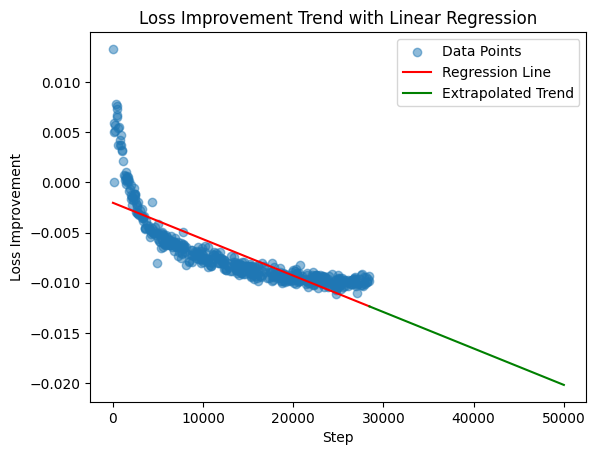

In [12]:

import numpy as np
from sklearn.linear_model import LinearRegression
X = merged[['_step']].values[:]
y = merged['loss_diff'].values[:]
model = LinearRegression()
model.fit(X, y)

# plot the regression line and extraplolate the trend until 50k steps
import matplotlib.pyplot as plt
plt.scatter(merged['_step'][:], merged['loss_diff'][:], alpha=0.5, label='Data Points')
plt.plot(merged['_step'], model.predict(merged[['_step']].values), color='red', label='Regression Line')
future_steps = np.arange(merged['_step'].max(), 50001).reshape(-1, 1)
plt.plot(future_steps, model.predict(future_steps), color='green', linestyle='-', label='Extrapolated Trend')
plt.xlabel('Step')
plt.ylabel('Loss Improvement')
plt.title('Loss Improvement Trend with Linear Regression')
plt.legend()
plt.show()

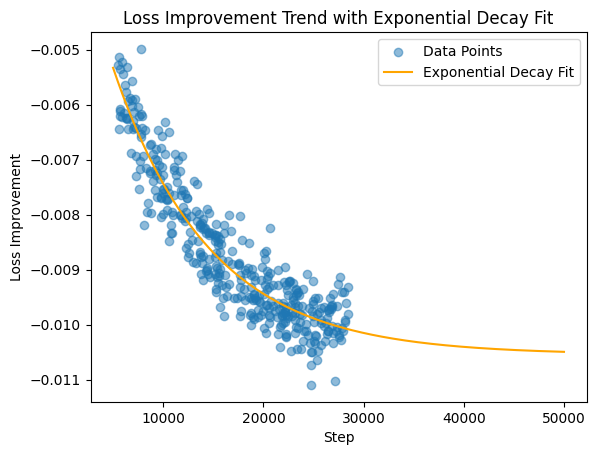

In [16]:
# fit an exponential decay model to the loss difference
from scipy.optimize import curve_fit
def exp_decay(x, a, b, c):
    return a * np.exp(-b * x) + c

start = 100
popt, pcov = curve_fit(exp_decay, merged['_step'][start:], merged['loss_diff'][start:], p0=(1, 0.0005, 0))
# plot the exponential decay fit and extrapolate to 50k steps
plt.scatter(merged['_step'][start:], merged['loss_diff'][start:], alpha=0.5, label='Data Points')
x_fit = np.linspace(5000, 50000, 1000)
y_fit = exp_decay(x_fit, *popt)
plt.plot(x_fit, y_fit, color='orange', label='Exponential Decay Fit')
plt.xlabel('Step')
plt.ylabel('Loss Improvement')
plt.title('Loss Improvement Trend with Exponential Decay Fit')
plt.legend()
plt.show()